# Are we paying a quality premium — or just paying a premium?

## Does higher price per unit actually buy better quality and fewer defects, or are we overspending for no gain?


###  Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import calendar

### Load Data

In [2]:
df = pd.read_csv('data/dataset.csv')

# Step 1 : Understand the Price Distribution First

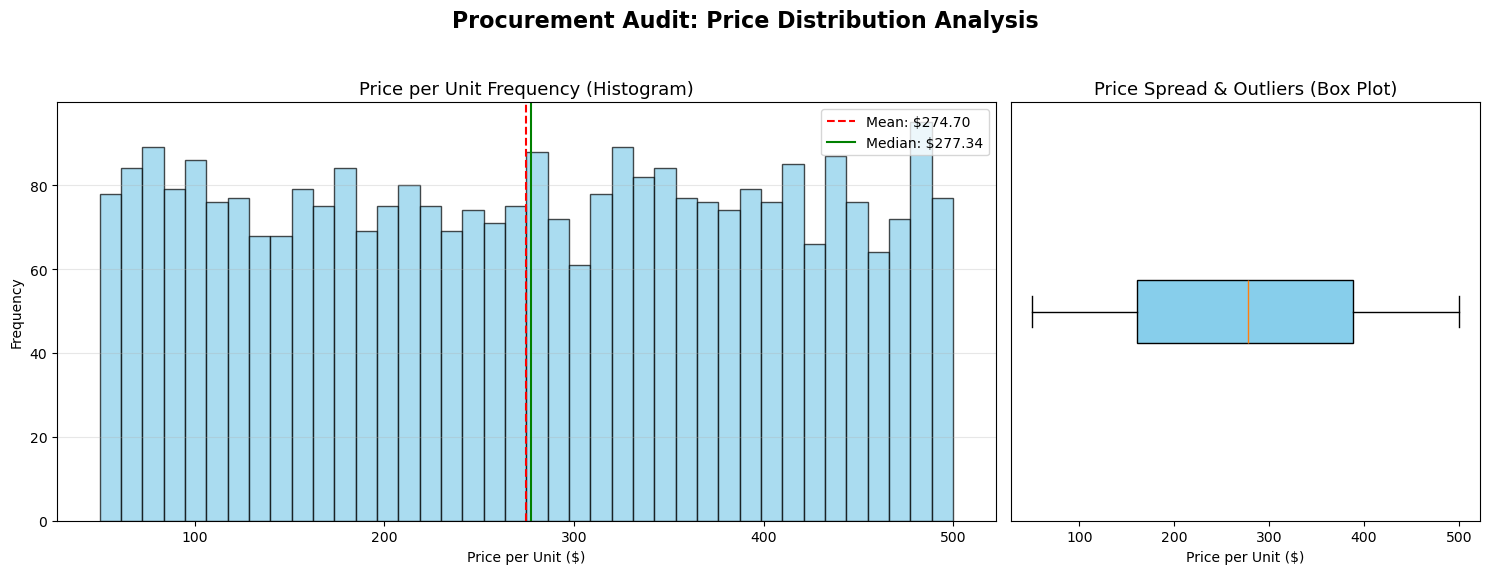

Price Audit Results:
- 50% of our items fall between $161.07 and $388.03
- We have 0 extreme price outliers (items over $728.47)


In [3]:


# 1. Setup the figure with two subplots
fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})

# 2. Histogram: Showing the "Humps" and Frequency
ax_hist.hist(df['price_per_unit'], bins=40, color='skyblue', edgecolor='black', alpha=0.7)
ax_hist.axvline(df['price_per_unit'].mean(), color='red', linestyle='--', label=f"Mean: ${df['price_per_unit'].mean():.2f}")
ax_hist.axvline(df['price_per_unit'].median(), color='green', linestyle='-', label=f"Median: ${df['price_per_unit'].median():.2f}")

ax_hist.set_title('Price per Unit Frequency (Histogram)', fontsize=13)
ax_hist.set_xlabel('Price per Unit ($)')
ax_hist.set_ylabel('Frequency')
ax_hist.legend()
ax_hist.grid(axis='y', alpha=0.3)

# 3. Box Plot: Identifying the "Outliers" (The Dots)
ax_box.boxplot(df['price_per_unit'], vert=False, patch_artist=True, 
               boxprops=dict(facecolor='skyblue', color='black'),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))

ax_box.set_title('Price Spread & Outliers (Box Plot)', fontsize=13)
ax_box.set_xlabel('Price per Unit ($)')
ax_box.set_yticks([]) # Hide Y-axis for the boxplot as it's one-dimensional

# 4. Final Layout
plt.suptitle('Procurement Audit: Price Distribution Analysis', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 5. Strategic Data Flagging
q1 = df['price_per_unit'].quantile(0.25)
q3 = df['price_per_unit'].quantile(0.75)
iqr = q3 - q1
outlier_threshold = q3 + 1.5 * iqr
outliers_count = len(df[df['price_per_unit'] > outlier_threshold])

print(f"Price Audit Results:")
print(f"- 50% of our items fall between ${q1:.2f} and ${q3:.2f}")
print(f"- We have {outliers_count} extreme price outliers (items over ${outlier_threshold:.2f})")

# Step 2 Price vs. Quality — The Core Scatter

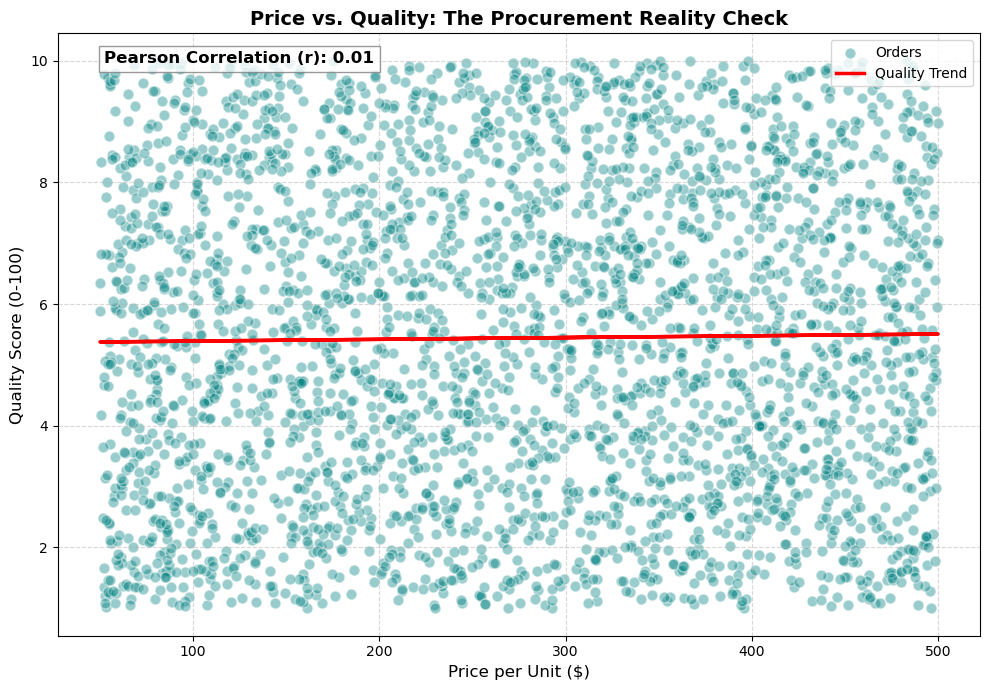

In [15]:

# 1. Prepare the data (Ensure no NaNs to avoid math errors)
clean_df = df[['price_per_unit', 'quality_score']].dropna()
x = clean_df['price_per_unit']
y = clean_df['quality_score']

# 2. Calculate Pearson Correlation (r) using NumPy
# np.corrcoef returns a correlation matrix; [0,1] gives the r value between x and y
correlation_matrix = np.corrcoef(x, y)
pearson_r = correlation_matrix[0, 1]

# 3. Calculate the Linear Regression Line (Best Fit)
# np.polyfit(x, y, 1) returns the slope (m) and intercept (b) for a degree-1 polynomial
m, b = np.polyfit(x, y, 1)

# 4. Create the Visualization
plt.figure(figsize=(10, 7))

# Scatter the raw data points
plt.scatter(x, y, alpha=0.4, color='teal', edgecolor='w', s=60, label='Orders')

# Plot the Regression Line (y = mx + b)
plt.plot(x, m*x + b, color='red', linewidth=2.5, label='Quality Trend')

# 5. Annotation & Polish
plt.title('Price vs. Quality: The Procurement Reality Check', fontsize=14, fontweight='bold')
plt.xlabel('Price per Unit ($)', fontsize=12)
plt.ylabel('Quality Score (0-100)', fontsize=12)

# Place the Pearson r value in a visible box
plt.text(0.05, 0.95, f'Pearson Correlation (r): {pearson_r:.2f}', 
         transform=plt.gca().transAxes, fontsize=12, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#### Key Takeway : We are not buying quality with our spending. Price and quality are completely disconnected.


# Step 3 Price vs. Defect Rate

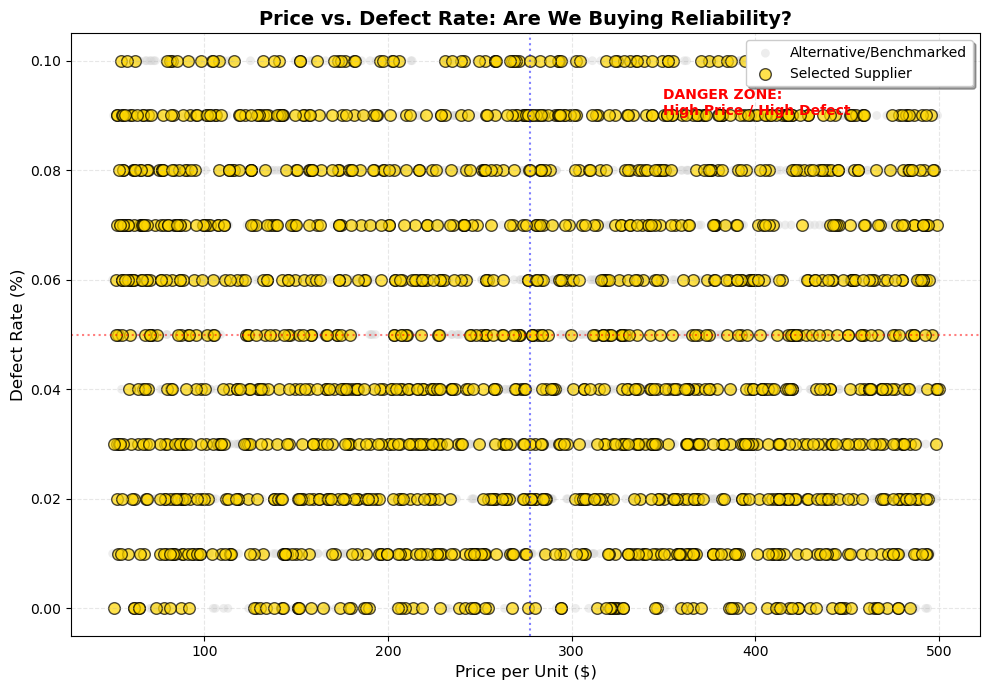

In [8]:
# 1. Setup the Color Mapping
color_map = {1: 'gold', 0: 'lightgray'}
label_map = {1: 'Selected Supplier', 0: 'Alternative/Benchmarked'}

# 2. Create the Visualization
plt.figure(figsize=(10, 7))

# We plot two separate scatters to easily create the legend
for flag in [0, 1]:
    mask = df['selected_supplier_flag'] == flag
    plt.scatter(df.loc[mask, 'price_per_unit'], 
                df.loc[mask, 'defect_rate'], 
                c=color_map[flag], 
                label=label_map[flag],
                alpha=0.7 if flag == 1 else 0.4,
                edgecolors='black' if flag == 1 else 'none',
                s=70 if flag == 1 else 40)

# 3. Polish and Context
plt.title('Price vs. Defect Rate: Are We Buying Reliability?', fontsize=14, fontweight='bold')
plt.xlabel('Price per Unit ($)', fontsize=12)
plt.ylabel('Defect Rate (%)', fontsize=12)

# Strategic Quadrant Lines (using medians as benchmarks)
plt.axhline(df['defect_rate'].median(), color='red', linestyle=':', alpha=0.5)
plt.axvline(df['price_per_unit'].median(), color='blue', linestyle=':', alpha=0.5)

plt.text(df['price_per_unit'].max()*0.7, df['defect_rate'].max()*0.9, 
         'DANGER ZONE:\nHigh Price / High Defect', color='red', fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

#### Key Takway : Paying more does not reduce defect rates. Current supplier selection is not defect-driven.


# Step 4 Price Buckets for Cleaner Analysis

C:\Users\Muhammad Tehseen\AppData\Local\Temp\ipykernel_10984\3333092340.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = df.groupby('price_bucket')[['quality_score', 'defect_rate', 'return_rate']].mean()


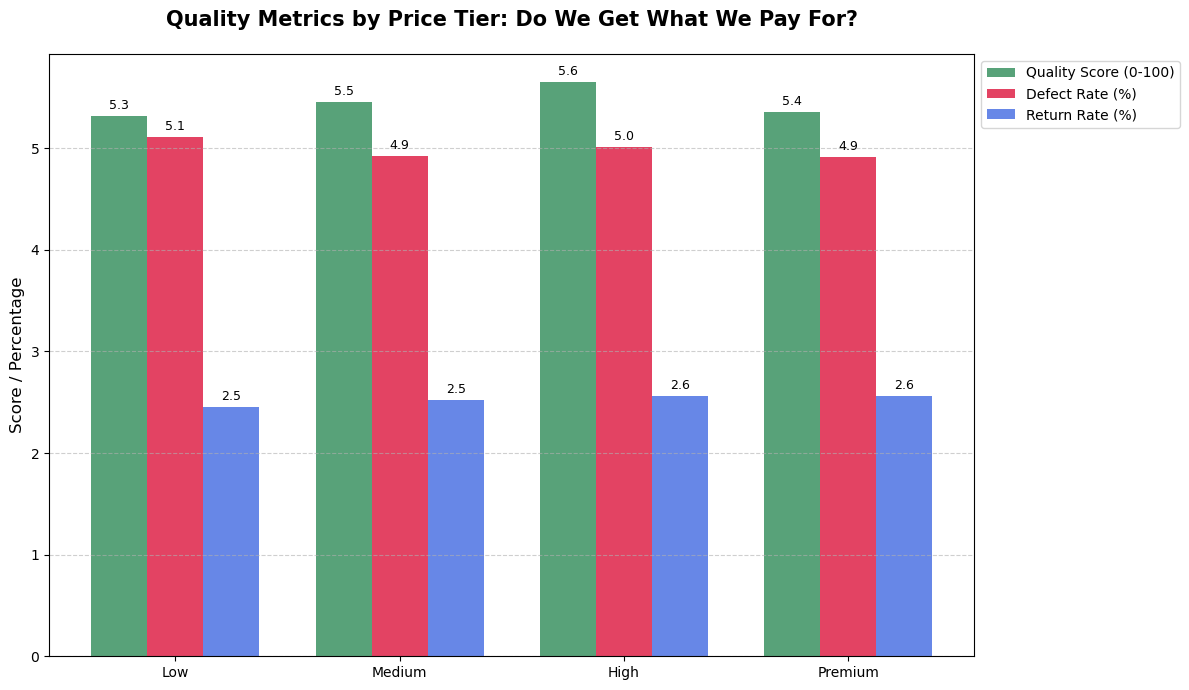

In [9]:

labels = ['Low', 'Medium', 'High', 'Premium']
df['price_bucket'] = pd.cut(df['price_per_unit'], bins=4, labels=labels)

bucket_stats = df.groupby('price_bucket')[['quality_score', 'defect_rate', 'return_rate']].mean()
bucket_stats['defect_rate_pct'] = bucket_stats['defect_rate'] * 100
bucket_stats['return_rate_pct'] = bucket_stats['return_rate'] * 100

# 3. Setup Grouped Bar Chart
x = np.arange(len(labels))  # The label locations
width = 0.25                # The width of the bars

fig, ax = plt.subplots(figsize=(12, 7))

# Plot each metric with a manual offset
rects1 = ax.bar(x - width, bucket_stats['quality_score'], width, label='Quality Score (0-100)', color='seagreen', alpha=0.8)
rects2 = ax.bar(x, bucket_stats['defect_rate_pct'], width, label='Defect Rate (%)', color='crimson', alpha=0.8)
rects3 = ax.bar(x + width, bucket_stats['return_rate_pct'], width, label='Return Rate (%)', color='royalblue', alpha=0.8)

# 4. Final Polish for the Boardroom
ax.set_title('Quality Metrics by Price Tier: Do We Get What We Pay For?', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Score / Percentage', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

#### Key Takeway: Price tier has zero operational impact. Low-tier and Premium-tier suppliers are interchangeable on all three quality metrics.


# Step 5 Procurement Action & Pricing

C:\Users\Muhammad Tehseen\AppData\Local\Temp\ipykernel_10984\629924947.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_to_plot, labels=ordered_codes, patch_artist=True,


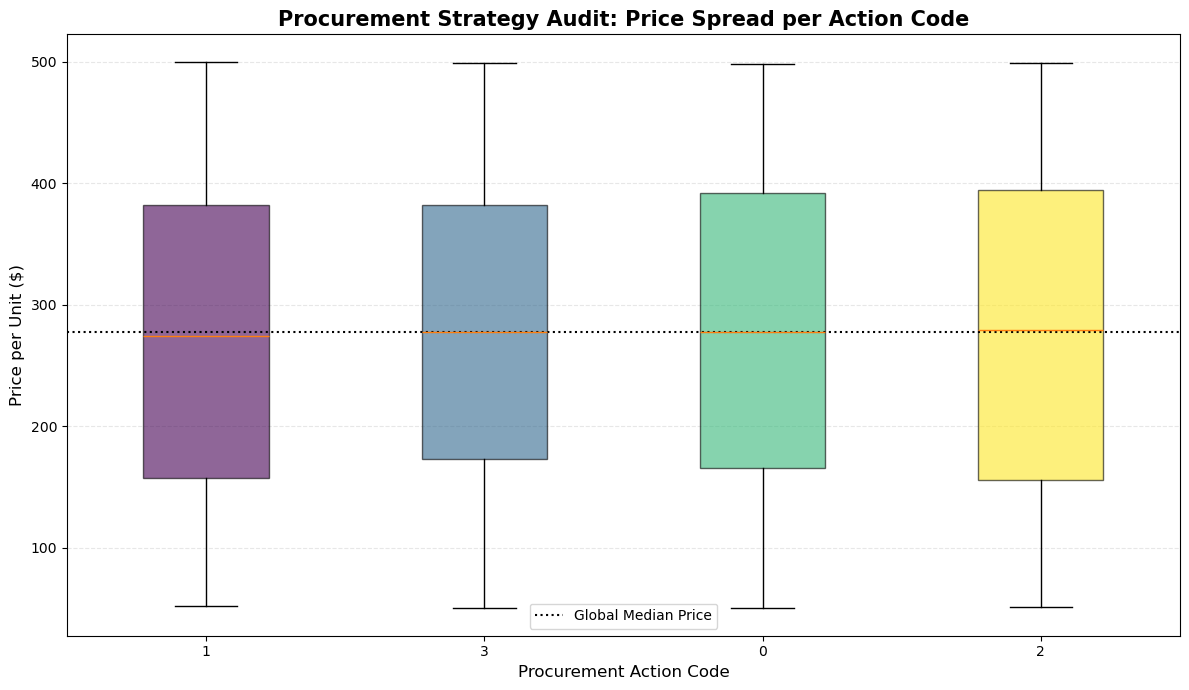

In [16]:
# 1. Prepare the Data
grouped = df.groupby('procurement_action_code')['price_per_unit'].median().sort_values()
ordered_codes = grouped.index.tolist()

# 2. Create the Visualization
plt.figure(figsize=(12, 7))

# Create a list of price arrays, one for each code in our sorted order
data_to_plot = [df[df['procurement_action_code'] == code]['price_per_unit'] for code in ordered_codes]

# Plotting the boxes
box = plt.boxplot(data_to_plot, labels=ordered_codes, patch_artist=True,
                  flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))

# 3. Styling for Impact
colors = plt.cm.viridis(np.linspace(0, 1, len(ordered_codes)))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 4. Final Polish
plt.title('Procurement Strategy Audit: Price Spread per Action Code', fontsize=15, fontweight='bold')
plt.xlabel('Procurement Action Code', fontsize=12)
plt.ylabel('Price per Unit ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add a horizontal line for the global median to show which strategies are "Expensive"
plt.axhline(df['price_per_unit'].median(), color='black', linestyle=':', label='Global Median Price')
plt.legend()

plt.tight_layout()
plt.show()

#### Takeway : Procurement action code does not drive price. Strategy type is not the cost lever — supplier selection is.



# Step 6 Return Rate as the Final Quality Verdict

C:\Users\Muhammad Tehseen\AppData\Local\Temp\ipykernel_10984\4266344875.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return_stats = df.groupby('price_bucket')['return_rate'].mean() * 100


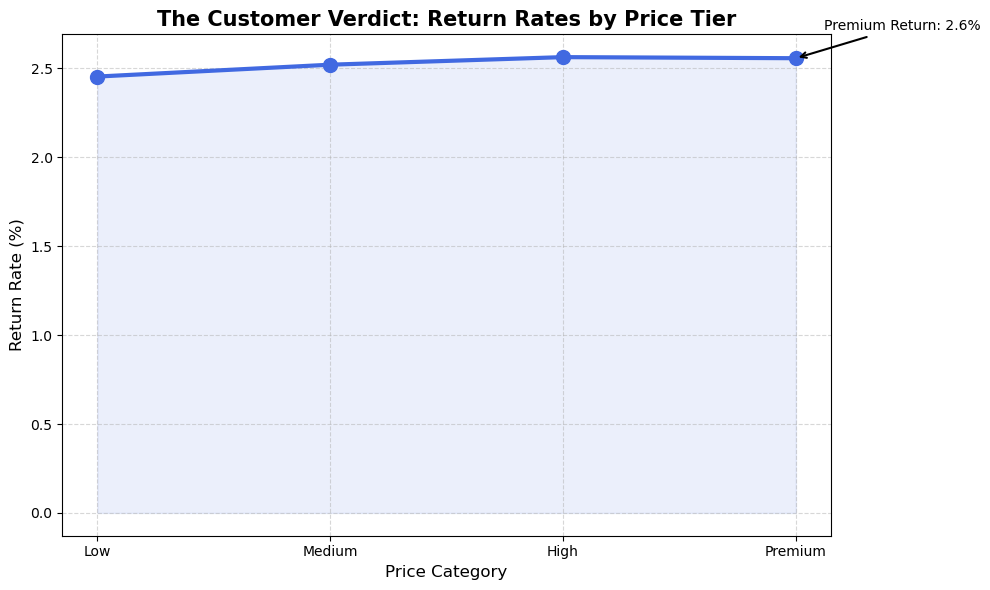

In [17]:
# 1. Aggregate the Return Rate by Bucket
return_stats = df.groupby('price_bucket')['return_rate'].mean() * 100 

# 2. Create the Visualization
plt.figure(figsize=(10, 6))

# Plotting the trend line
plt.plot(return_stats.index, return_stats.values, marker='o', linestyle='-', 
         color='royalblue', linewidth=3, markersize=10, label='Avg Return Rate')

# 3. Add a "Shadow" to highlight the area
plt.fill_between(return_stats.index, return_stats.values, color='royalblue', alpha=0.1)

# 4. Boardroom Annotations
plt.title('The Customer Verdict: Return Rates by Price Tier', fontsize=15, fontweight='bold')
plt.xlabel('Price Category', fontsize=12)
plt.ylabel('Return Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Highlight the "Premium" data point specifically
premium_val = return_stats['Premium']
plt.annotate(f'Premium Return: {premium_val:.1f}%', 
             xy=('Premium', premium_val), xytext=(20, 20),
             textcoords='offset points', 
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

plt.tight_layout()
plt.show()

#### Takeway : This is the most boardroom-ready finding in Q3. Premium price = premium returns. The price-quality narrative is completely false.


# Step 7 Correlation Heatmap — Tie It All Together

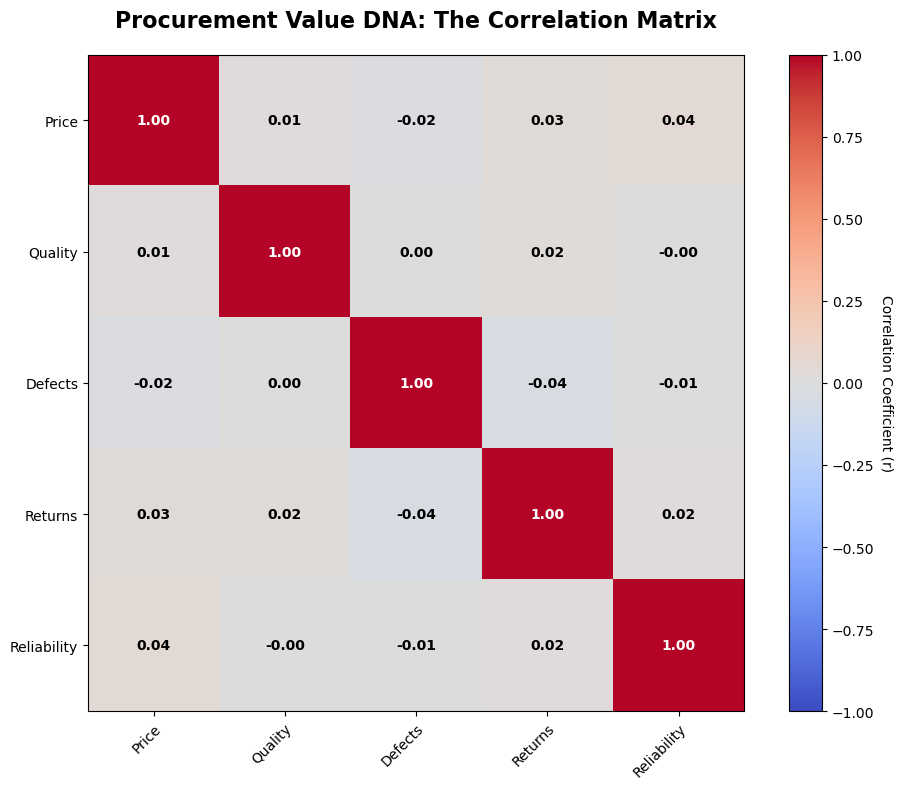

In [18]:

# 1. Select the Core variables for the Q3 Argument
cols = ['price_per_unit', 'quality_score', 'defect_rate', 
        'return_rate', 'supplier_reliability_score']
corr_matrix = df[cols].corr()

# 2. Setup the Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# 3. Add the Colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Correlation Coefficient (r)", rotation=-90, va="bottom")

# 4. Annotate the Matrix (The values inside the boxes)
for i in range(len(cols)):
    for j in range(len(cols)):
        text = ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                       ha="center", va="center", 
                       color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black",
                       fontweight='bold')

# 5. Labeling and Polish
ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(['Price', 'Quality', 'Defects', 'Returns', 'Reliability'])
ax.set_yticklabels(['Price', 'Quality', 'Defects', 'Returns', 'Reliability'])

# Rotate the tick labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

plt.title('Procurement Value DNA: The Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#### Takeway : The procurement value chain is entirely disconnected. Price tells us nothing about any outcome.
 